# Score V3: DivEye-Inspired Second-Order Surprisal Features

Based on DivEye (Basani & Chen, TMLR 2026): second-order surprisal dynamics
are the strongest discriminator (39.4% contribution), robust to paraphrasing.

Key insight: Humanization changes WHICH tokens are surprising but cannot
fake the TEMPORAL PATTERN of how surprise evolves.
- Human: bursty surprisal (clusters of predictable then creative) → high variance of diffs
- AI: uniform low surprisal → low variance
- Humanized: uniform HIGH surprisal → low variance of diffs

Both AI and humanized have LOW variance of surprisal diffs, but different means.
Combining R(s) (captures mean) with diff_variance (captures pattern) should detect both.

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch==2.5.1+cu121', 'torchvision==0.20.1+cu121', '--index-url', 'https://download.pytorch.org/whl/cu121', '-q'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'transformers==4.46.3', 'accelerate==1.1.1', 'bitsandbytes', 'scipy', 'scikit-learn', '-q'])
import torch; print(f'PyTorch {torch.__version__}, CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0); print(f'GPU: {p.name}, compute {p.major}.{p.minor}')
    x = torch.randn(2,2).cuda(); print(f'OK: {(x@x).sum().item():.2f}'); del x

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 107.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 69.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 48.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 50.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.5.1+cu121 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 92.8 MB/s eta 0:00:00
PyTorch 2.5.1+cu121, CUDA: True
GPU: Tesla P100-PCIE-16GB, compute 6.0
OK: 4.32


In [2]:
import gc, os, sys, json, shutil, warnings
import numpy as np
import torch, torch.nn.functional as F
from tqdm import tqdm
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
BASE = '/kaggle/input'
df = ds = None
for r, dirs, files in os.walk(BASE):
    for f in files:
        if f == 'multimodel_p5e_dataset.json': df = os.path.join(r, f)
        if f == '__init__.py' and 'dna_detectllm' in r: ds = os.path.dirname(os.path.join(r, f))
if not os.path.exists('dna_detectllm') and ds: shutil.copytree(ds, 'dna_detectllm', dirs_exist_ok=True)
sys.path.insert(0, os.getcwd())
from dna_detectllm.metrics import sum_perplexity, entropy
os.environ['HF_TOKEN'] = 'YOUR_HF_TOKEN'
with open(df) as f: dataset = json.load(f)
print(f'Loaded. Human={len(dataset["human_texts"])}, AI={len(dataset["original_ai_texts"])}')

Loaded. Human=100, AI=100


In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import ctypes
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
gc.collect(); torch.cuda.empty_cache()
tokenizer = AutoTokenizer.from_pretrained('tiiuae/falcon-7b')
tokenizer.pad_token = tokenizer.eos_token
MAX_LEN = 256; DEVICE = 'cuda:0'
cc = torch.cuda.get_device_properties(0)
if (cc.major, cc.minor) >= (7,0):
    from transformers import BitsAndBytesConfig
    qc = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type='nf4')
    lk = dict(quantization_config=qc, device_map='auto', low_cpu_mem_usage=True); MAX_LEN = 512
else:
    lk = dict(torch_dtype=torch.float16, device_map='auto', low_cpu_mem_usage=True)
observer = AutoModelForCausalLM.from_pretrained('tiiuae/falcon-7b', **lk); observer.eval()
gc.collect(); torch.cuda.empty_cache()
try: ctypes.CDLL('libc.so.6').malloc_trim(0)
except: pass
performer = AutoModelForCausalLM.from_pretrained('tiiuae/falcon-7b-instruct', **lk); performer.eval()
print(f'Models loaded. MAX_LEN={MAX_LEN}')

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

2026-04-15 13:35:05.973574: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776260106.173544      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776260106.226515      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776260106.679547      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776260106.679592      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776260106.679595      23 computation_placer.cc:177] computation placer alr

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.48G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

Models loaded. MAX_LEN=256


In [4]:
@torch.inference_mode()
def compute_v3(text):
    torch.cuda.empty_cache()
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_LEN, return_token_type_ids=False)
    eg = {k: v.to(DEVICE) for k, v in enc.items()}
    ol = observer(**eg).logits.float()
    pl = performer(**eg).logits.float()
    
    # Standard R(s)
    class E:
        def __init__(s, d): s.input_ids = d['input_ids']; s.attention_mask = d['attention_mask']
        def to(s, dev): s.input_ids = s.input_ids.to(dev); s.attention_mask = s.attention_mask.to(dev); return s
    eo = E(eg)
    ppl = sum_perplexity(eo, pl)
    xppl = entropy(ol, pl, eo, tokenizer.pad_token_id)
    rs = float(ppl[0] / (2 * xppl[0]))
    
    # Per-token surprisal sequence
    shifted = pl[..., :-1, :]
    labels = eg['input_ids'][..., 1:]
    attn = eg['attention_mask'][..., 1:]
    ce = F.cross_entropy(shifted.transpose(1,2), labels, reduction='none')
    S = ce[attn.bool()].cpu().numpy()
    
    if len(S) < 5:
        del ol, pl, eg
        return None
    
    # === DivEye-inspired features ===
    # Distributional
    f_mean = float(np.mean(S))
    f_var = float(np.var(S))
    f_skew = float(stats.skew(S))
    f_kurt = float(stats.kurtosis(S))
    
    # First-order dynamics
    dS = np.diff(S)
    f_d_var = float(np.var(dS))  # KEY: variance of surprisal changes
    
    # Second-order dynamics
    d2S = np.diff(dS)
    f_d2_var = float(np.var(d2S))  # KEY: acceleration variance
    f_d2_autocorr = float(np.corrcoef(d2S[:-1], d2S[1:])[0,1]) if len(d2S) > 2 else 0
    
    # Performer entropy at each position
    pe = -(F.softmax(pl[..., :-1, :], dim=-1) * F.log_softmax(pl[..., :-1, :], dim=-1)).sum(-1)
    H = pe[attn.bool()].cpu().numpy()
    f_H_var = float(np.var(H))
    
    # Confidence-surprise coherence (Idea 3 from research)
    H_median = np.median(H)
    confident = H < H_median
    if confident.sum() > 0 and (~confident).sum() > 0:
        f_coherence = float(np.mean(S[confident]) - np.mean(S[~confident]))
    else:
        f_coherence = 0.0
    
    # Token rank bimodality
    probs = F.softmax(shifted, dim=-1)
    act_p = probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)
    ranks = (probs > act_p.unsqueeze(-1)).sum(-1) + 1
    lr = torch.log(ranks.float())[attn.bool()].cpu().numpy()
    f_rank_bimodal = float((stats.skew(lr)**2 + 1) / (stats.kurtosis(lr) + 3 + 1e-10)) if len(lr) > 3 else 0
    
    del ol, pl, eg
    return {'rs': rs, 's_mean': f_mean, 's_var': f_var, 's_skew': f_skew, 's_kurt': f_kurt,
            'd_var': f_d_var, 'd2_var': f_d2_var, 'd2_autocorr': f_d2_autocorr,
            'H_var': f_H_var, 'coherence': f_coherence, 'rank_bimodal': f_rank_bimodal}

test = compute_v3('Hello world this is a test sentence for checking.')
print(f'Test: {test}')

Test: {'rs': 0.6789847612380981, 's_mean': 4.421363830566406, 's_var': 5.412387371063232, 's_skew': -0.2758835554122925, 's_kurt': -1.1746331453323364, 'd_var': 13.610462188720703, 'd2_var': 45.55854415893555, 'd2_autocorr': -0.7951595478396756, 'H_var': 1.7933506965637207, 'coherence': -1.4974663257598877, 'rank_bimodal': 0.538542628288269}


In [5]:
# Score all groups
CKPT = 'v3_checkpoint.json'
if os.path.exists(CKPT):
    all_v3 = json.load(open(CKPT)); print(f'Checkpoint: {list(all_v3.keys())}')
else:
    all_v3 = {}
groups = {'human': dataset['human_texts'], 'original_ai': dataset['original_ai_texts']}
for mk in ['moonshotai_kimi-k2-instruct', 'gemini-2.0-flash', 'qwen_qwen3-32b']:
    if mk in dataset['humanized']: groups[mk] = dataset['humanized'][mk]
for gn, texts in groups.items():
    if gn in all_v3: print(f'{gn}: done'); continue
    print(f'Scoring {gn}...')
    sc = []
    for t in tqdm(texts, desc=gn):
        if t is None: sc.append(None)
        else:
            try: sc.append(compute_v3(t))
            except Exception as e: print(f'Err: {e}'); sc.append(None)
    all_v3[gn] = sc
    with open(CKPT, 'w') as f: json.dump(all_v3, f)
print('Done!')

Scoring human...


human: 100%|██████████| 100/100 [07:06<00:00,  4.27s/it]


Scoring original_ai...


original_ai: 100%|██████████| 100/100 [07:16<00:00,  4.36s/it]


Scoring moonshotai_kimi-k2-instruct...


...

Scoring gemini-2.0-flash...


gemini-2.0-flash: 100%|██████████| 100/100 [07:16<00:00,  4.37s/it]


Scoring qwen_qwen3-32b...


qwen_qwen3-32b: 100%|██████████| 100/100 [07:15<00:00,  4.35s/it]

Done!


In [6]:
# === ANALYSIS ===
feats = ['rs', 's_var', 'd_var', 'd2_var', 'd2_autocorr', 'H_var', 'coherence', 'rank_bimodal']
glabels = {'human': 'Human', 'original_ai': 'AI', 'moonshotai_kimi-k2-instruct': 'Kimi', 'gemini-2.0-flash': 'Gemini'}

print('=== FEATURE MEANS ===')
print(f'{"":<15}', end=''); [print(f' {glabels.get(g,g):>8}', end='') for g in glabels]; print()
for feat in feats:
    print(f'{feat:<15}', end='')
    for g in glabels:
        vals = [s[feat] for s in all_v3.get(g,[]) if s]
        print(f' {np.mean(vals):>8.4f}', end='')
    print()

print('\n=== AUROC BY INDIVIDUAL FEATURE (higher=human) ===')
print(f'{"Feature":<15} {"H vs AI":>8} {"H vs Kimi":>10} {"H vs Gem":>9}')
hv = {f: [s[f] for s in all_v3.get('human',[]) if s] for f in feats}
for feat in feats:
    av = [s[feat] for s in all_v3.get('original_ai',[]) if s]
    kv = [s[feat] for s in all_v3.get('moonshotai_kimi-k2-instruct',[]) if s]
    gv = [s[feat] for s in all_v3.get('gemini-2.0-flash',[]) if s]
    a1 = roc_auc_score([1]*len(hv[feat])+[0]*len(av), hv[feat]+av)
    a2 = roc_auc_score([1]*len(hv[feat])+[0]*len(kv), hv[feat]+kv) if kv else 0
    a3 = roc_auc_score([1]*len(hv[feat])+[0]*len(gv), hv[feat]+gv) if gv else 0
    print(f'{feat:<15} {a1:>8.4f} {a2:>10.4f} {a3:>9.4f}')

# === LogReg with best features ===
print('\n=== LOGISTIC REGRESSION ===')
best_feats = ['rs', 's_var', 'd_var', 'd2_var', 'H_var', 'coherence']
X_h = np.array([[s[f] for f in best_feats] for s in all_v3.get('human',[]) if s])
X_ai = np.array([[s[f] for f in best_feats] for s in all_v3.get('original_ai',[]) if s])
X_k = np.array([[s[f] for f in best_feats] for s in all_v3.get('moonshotai_kimi-k2-instruct',[]) if s])
X_g = np.array([[s[f] for f in best_feats] for s in all_v3.get('gemini-2.0-flash',[]) if s])

if len(X_h) and len(X_ai):
    Xt = np.vstack([X_h, X_ai]); yt = np.array([1]*len(X_h)+[0]*len(X_ai))
    sc = StandardScaler(); Xts = sc.fit_transform(Xt)
    clf = LogisticRegression(max_iter=1000); clf.fit(Xts, yt)
    print(f'Train (H vs AI): {roc_auc_score(yt, clf.predict_proba(Xts)[:,1]):.4f}')
    if len(X_k):
        Xtest = np.vstack([X_h, X_k]); ytest = [1]*len(X_h)+[0]*len(X_k)
        print(f'Test (H vs Kimi): {roc_auc_score(ytest, clf.predict_proba(sc.transform(Xtest))[:,1]):.4f}')
    if len(X_g):
        Xtest = np.vstack([X_h, X_g]); ytest = [1]*len(X_h)+[0]*len(X_g)
        print(f'Test (H vs Gem):  {roc_auc_score(ytest, clf.predict_proba(sc.transform(Xtest))[:,1]):.4f}')
    print(f'Coefficients: {dict(zip(best_feats, clf.coef_[0].round(3)))}')

# === Zero-shot combined score: R(s) * sqrt(d_var) ===
print('\n=== ZERO-SHOT R_robust = R(s) * sigmoid(d_var) ===')
from scipy.special import expit
hd = [s['d_var'] for s in all_v3.get('human',[]) if s]
dm, ds_ = np.mean(hd), np.std(hd)
def R_robust(s):
    burst = expit((s['d_var'] - dm) / max(ds_, 0.001))
    return s['rs'] * burst

for label, gname in [('H vs AI', 'original_ai'), ('H vs Kimi', 'moonshotai_kimi-k2-instruct'), ('H vs Gem', 'gemini-2.0-flash')]:
    hsc = [R_robust(s) for s in all_v3.get('human',[]) if s]
    gsc = [R_robust(s) for s in all_v3.get(gname,[]) if s]
    if hsc and gsc:
        print(f'{label}: AUROC={roc_auc_score([1]*len(hsc)+[0]*len(gsc), hsc+gsc):.4f}')
print('\nReference R(s) alone:')
for label, gname in [('H vs AI', 'original_ai'), ('H vs Kimi', 'moonshotai_kimi-k2-instruct'), ('H vs Gem', 'gemini-2.0-flash')]:
    hsc = [s['rs'] for s in all_v3.get('human',[]) if s]
    gsc = [s['rs'] for s in all_v3.get(gname,[]) if s]
    if hsc and gsc:
        print(f'{label}: AUROC={roc_auc_score([1]*len(hsc)+[0]*len(gsc), hsc+gsc):.4f}')

=== FEATURE MEANS ===
                   Human       AI     Kimi   Gemini
rs                0.7017   0.6024   0.7343   0.7061
s_var             6.2366   5.7730   9.4453   8.5808
d_var            12.0698  11.4050  19.4392  17.6548
d2_var           36.2262  34.0932  58.7200  53.5943
d2_autocorr      -0.6657  -0.6607  -0.6654  -0.6723
H_var             2.5473   2.4613   3.0192   2.6291
coherence        -2.4107  -2.4254  -3.0681  -2.9569
rank_bimodal      0.6650   0.6765   0.6677   0.6412

=== AUROC BY INDIVIDUAL FEATURE (higher=human) ===
Feature          H vs AI  H vs Kimi  H vs Gem
rs                0.9916     0.2056    0.4650
s_var             0.6024     0.0346    0.0763
d_var             0.5818     0.0248    0.0581
d2_var            0.5826     0.0318    0.0659
d2_autocorr       0.4645     0.4929    0.5432
H_var             0.5633     0.1924    0.4498
coherence         0.5105     0.8954    0.8650
rank_bimodal      0.4143     0.4881    0.6832

=== LOGISTIC REGRESSION ===
Train (H vs AI)

Saved v3_results.json


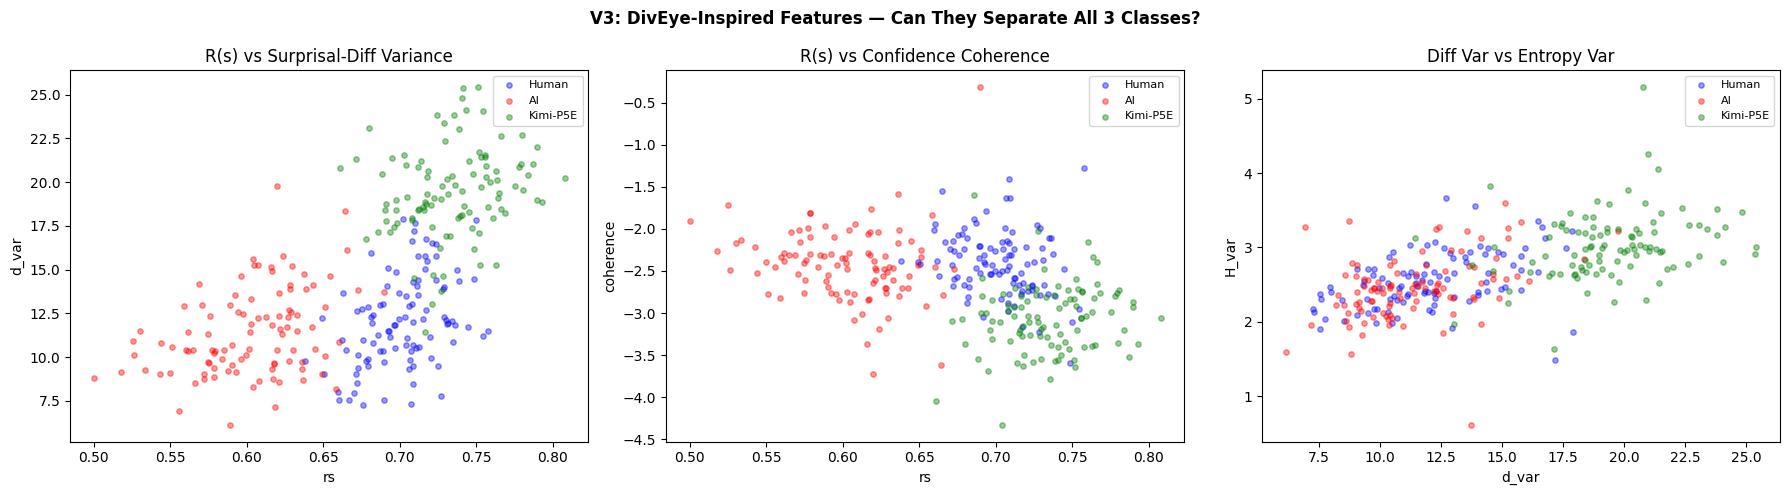

In [7]:
# Save and plot
with open('v3_results.json', 'w') as f: json.dump({'features': feats, 'data': {k: [s for s in v if s] for k,v in all_v3.items()}}, f, indent=2)
print('Saved v3_results.json')

if len(X_h) and len(X_ai) and len(X_k):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, (fx, fy, t) in enumerate([('rs','d_var','R(s) vs Surprisal-Diff Variance'),('rs','coherence','R(s) vs Confidence Coherence'),('d_var','H_var','Diff Var vs Entropy Var')]):
        ix, iy = best_feats.index(fx), best_feats.index(fy)
        axes[i].scatter(X_h[:,ix], X_h[:,iy], c='blue', alpha=0.4, s=15, label='Human')
        axes[i].scatter(X_ai[:,ix], X_ai[:,iy], c='red', alpha=0.4, s=15, label='AI')
        axes[i].scatter(X_k[:,ix], X_k[:,iy], c='green', alpha=0.4, s=15, label='Kimi-P5E')
        axes[i].set_xlabel(fx); axes[i].set_ylabel(fy); axes[i].set_title(t); axes[i].legend(fontsize=8)
    plt.suptitle('V3: DivEye-Inspired Features — Can They Separate All 3 Classes?', fontweight='bold')
    plt.tight_layout(); plt.savefig('v3_scatter.png', dpi=150); plt.show()